In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.preprocessing import StandardScaler

In [3]:
X, y = make_regression(n_samples=300, n_features=1, noise=15, random_state=42)

print("Dataset Shape:", X.shape)

Dataset Shape: (300, 1)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Training size: 240
Testing size: 60


In [5]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [6]:
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

In [7]:
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2 Score:", r2_score(y_test, y_test_pred))

MSE: 240.04754147865052
MAE: 12.011694397162847
R2 Score: 0.7986359417447673


In [8]:
print("Intercept:", linear_model.intercept_)
print("Coefficient:", linear_model.coef_[0])


Intercept: 0.30645400056103955
Coefficient: 27.611475815437633


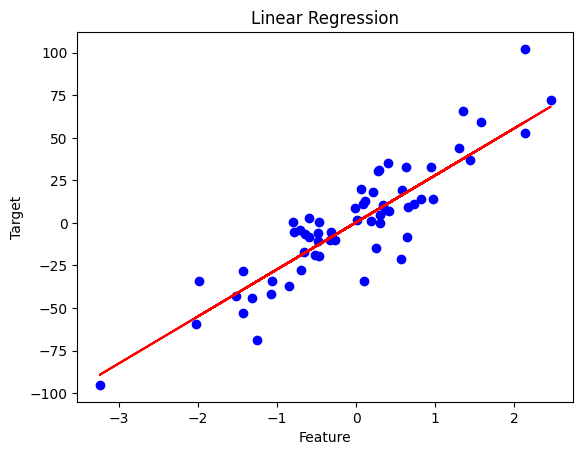

In [9]:
plt.scatter(X_test, y_test, color="blue")
plt.plot(X_test, y_test_pred, color="red")
plt.title("Linear Regression")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.show()

In [10]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)

Dataset Shape: (569, 30)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
y_pred = log_model.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9824561403508771
Precision: 0.9906542056074766
Recall: 0.9814814814814815
F1 Score: 0.986046511627907


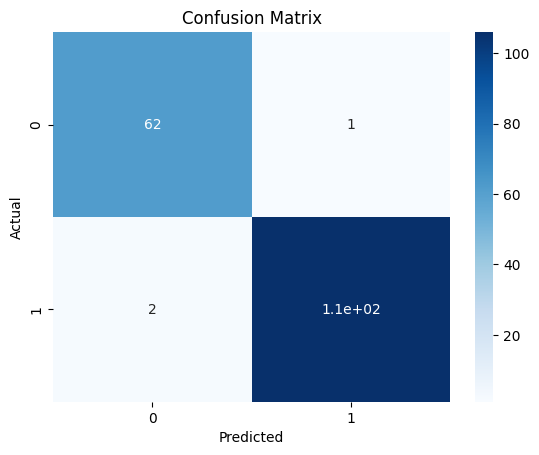

In [16]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()